#AI Term Project (BLG 521E) - Uncertainty Quantification in Medical Image Classification: Applying Conformal Prediction to TissueMNIST with ResNet-50 (28)
* Sedef Kjamili (504251563)

In [2]:
!pip install medmnist mapie -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.4/265.4 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 13.7 MB/s eta 0:00:00


Device: cuda
Dataset: tissuemnist | sinif sayisi: 8

Indiriliyor...
Agirliklar hazir.


100%|██████████| 125M/125M [00:07<00:00, 16.9MB/s]



=== run_1 ===
  Val olasiliklari...
  Test olasiliklari...
  Test Accuracy: 0.6769 | Macro AUC: 0.9291

=== run_2 ===
  Val olasiliklari...
  Test olasiliklari...
  Test Accuracy: 0.6785 | Macro AUC: 0.9319

=== run_3 ===
  Val olasiliklari...
  Test olasiliklari...
  Test Accuracy: 0.6844 | Macro AUC: 0.9332

========= Checkpoint karsilastirmasi =========
Run          Accuracy  Macro AUC
--------------------------------
run_1          0.6769     0.9291
run_2          0.6785     0.9319
run_3          0.6844     0.9332

En iyi: run_3 (acc=0.6844)

========= En iyi model test sonuclari (run_3) =========
Test Accuracy:   0.6844
Macro AUC (OvR): 0.9332

                                    precision    recall  f1-score   support

          Distal Convoluted Tubule     0.5702    0.3000    0.3932      2233
      Glomerular endothelial cells     0.5797    0.3709    0.4524      1677
    Interstitial endothelial cells     0.6815    0.6104    0.6440      4402
                        Leukocytes  

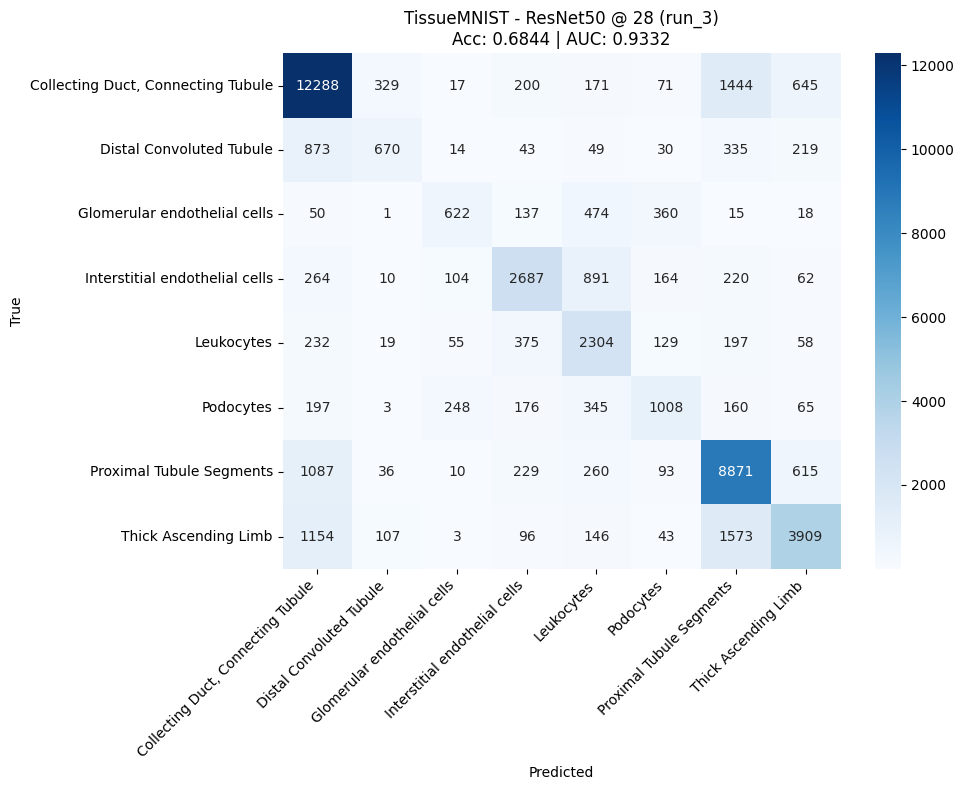


========= Conformal yontem karsilastirmasi (confidence=0.90) =========
Yontem       Coverage   Avg Size     Median
--------------------------------------------
lac            0.8996      2.009        2.0
aps            0.9439      2.589        2.0
top_k          0.9354      3.030        3.0


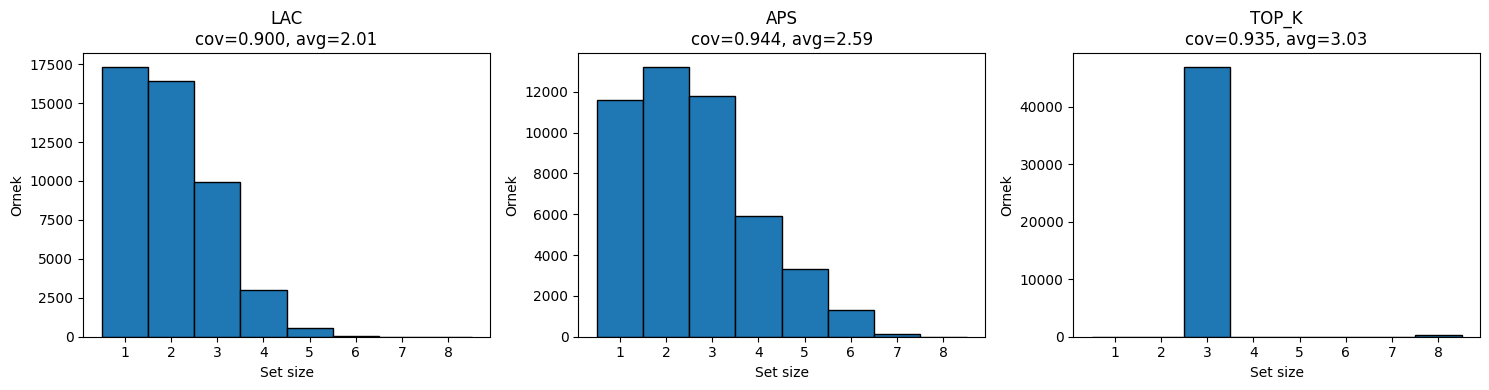


========= Confidence trade-off (LAC) =========
  Conf    Hedef   Gercek   Avg Size
------------------------------------
  0.80   80.00%   79.93%      1.370
  0.85   85.00%   84.77%      1.625
  0.90   90.00%   89.96%      2.009
  0.95   95.00%   94.91%      2.648
  0.99   99.00%   99.00%      4.106


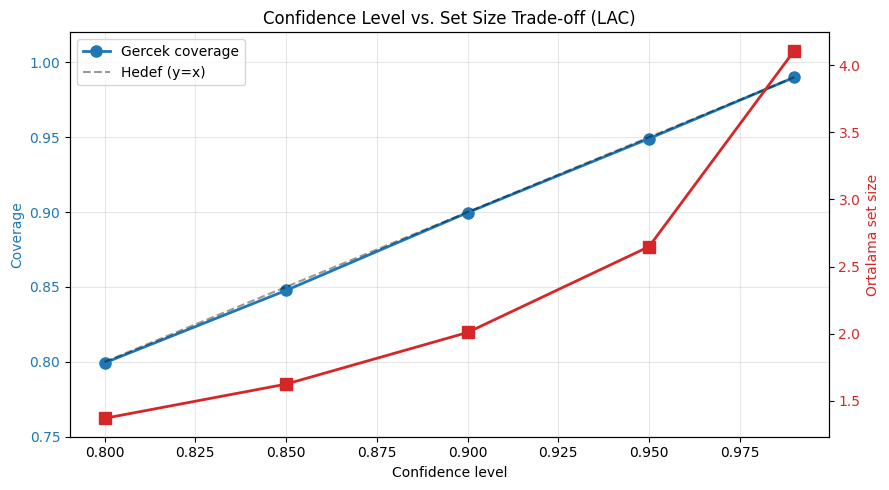

  RESNET-50 + SINIF KOSULLU (CLASS-CONDITIONAL) SONUCLAR

--- %95 GUVEN ICIN SINIF KOSULLU ESIKLER ---
Sinif 0 (Collecting Duct, Conne) Esik / Threshold: 0.0979
Sinif 1 (Distal Convoluted Tubu) Esik / Threshold: 0.0086
Sinif 2 (Glomerular endothelial) Esik / Threshold: 0.0146
Sinif 3 (Interstitial endotheli) Esik / Threshold: 0.0416
Sinif 4 (Leukocytes            ) Esik / Threshold: 0.0258
Sinif 5 (Podocytes             ) Esik / Threshold: 0.0132
Sinif 6 (Proximal Tubule Segmen) Esik / Threshold: 0.0854
Sinif 7 (Thick Ascending Limb  ) Esik / Threshold: 0.0268

  CLASS-CONDITIONAL LAC SONUCLAR (Test Set)

Genel Kapsama (Global Coverage): %95.11
Ortalama Kume Boyutu (Mean Set Size): 2.95

--- Sinif Bazli Kapsama (Per-Class Coverage) ---
Distal      : %96.24
Glomerular  : %95.71
Interstitia : %94.23
Leukocytes  : %94.36
Podocytes   : %96.00
Proximal    : %94.80
Thick       : %95.46

=== TUM ANALIZ TAMAMLANDI ===
Olusturulan dosyalar: confusion_matrix.png, method_comparison.png, tradeoff.

In [3]:
# ==========================================================================
# TissueMNIST — ResNet-50 @ 28 + Conformal Prediction (Tek hucre)
# ==========================================================================

import os
import zipfile
import urllib.request

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms

import medmnist
from medmnist import INFO

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    confusion_matrix, classification_report,
)
from mapie.classification import SplitConformalClassifier

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm


# --------------------------------------------------------------------------
# 1) KONFIGURASYON
# --------------------------------------------------------------------------
DATA_FLAG    = "tissuemnist"
ZENODO_URL   = "https://zenodo.org/records/7782114/files/weights_tissuemnist.zip?download=1"
ZIP_PATH     = "weights_tissuemnist.zip"
WEIGHTS_DIR  = "weights_tissuemnist"
BATCH_SIZE   = 128
NUM_WORKERS  = 2
ALPHA        = 0.05  # %95 guven seviyesi (class-conditional LAC icin)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

info = INFO[DATA_FLAG]
n_classes   = len(info["label"])
class_names = [info["label"][str(i)] for i in range(n_classes)]
DataClass   = getattr(medmnist, info["python_class"])
print(f"Dataset: {DATA_FLAG} | sinif sayisi: {n_classes}")


# --------------------------------------------------------------------------
# 2) AGIRLIKLARI INDIR
# --------------------------------------------------------------------------
if not os.path.exists(ZIP_PATH):
    print("\nIndiriliyor...")
    urllib.request.urlretrieve(ZENODO_URL, ZIP_PATH)
if not os.path.exists(WEIGHTS_DIR):
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(WEIGHTS_DIR)
print("Agirliklar hazir.")


# --------------------------------------------------------------------------
# 3) MEDMNIST'IN KENDI RESNET-50 MIMARISI (28x28 icin)
# --------------------------------------------------------------------------
class Bottleneck(nn.Module):
    expansion = 4
    def __init__(self, in_planes, planes, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, 1, bias=False)
        self.bn1   = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, 3, stride, 1, bias=False)
        self.bn2   = nn.BatchNorm2d(planes)
        self.conv3 = nn.Conv2d(planes, self.expansion * planes, 1, bias=False)
        self.bn3   = nn.BatchNorm2d(self.expansion * planes)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion * planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion * planes, 1, stride, bias=False),
                nn.BatchNorm2d(self.expansion * planes)
            )
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = F.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        out += self.shortcut(x)
        return F.relu(out)

class MedResNet(nn.Module):
    def __init__(self, block, num_blocks, in_channels, num_classes):
        super().__init__()
        self.in_planes = 64
        self.conv1 = nn.Conv2d(in_channels, 64, 3, 1, 1, bias=False)
        self.bn1   = nn.BatchNorm2d(64)
        self.layer1 = self._make_layer(block, 64,  num_blocks[0], 1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], 2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], 2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], 2)
        self.linear = nn.Linear(512 * block.expansion, num_classes)
    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(block(self.in_planes, planes, s))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out); out = self.layer2(out)
        out = self.layer3(out); out = self.layer4(out)
        out = F.adaptive_avg_pool2d(out, 1).view(out.size(0), -1)
        return self.linear(out)

def MedResNet50(in_channels, num_classes):
    return MedResNet(Bottleneck, [3, 4, 6, 3], in_channels, num_classes)


# --------------------------------------------------------------------------
# 4) VERI YUKLEYICI (28x28, tek kanal)
# --------------------------------------------------------------------------
transform_28 = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

val_dataset  = DataClass(split="val",  transform=transform_28, download=True)
test_dataset = DataClass(split="test", transform=transform_28, download=True)
val_loader   = DataLoader(val_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

@torch.no_grad()
def get_probs_and_labels(loader, model, device):
    model.eval()
    all_probs, all_labels = [], []
    for images, labels in loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(labels.squeeze().long().numpy())
    return np.concatenate(all_probs), np.concatenate(all_labels)

def load_model(ckpt_path):
    m = MedResNet50(in_channels=3, num_classes=n_classes).to(device)
    sd = torch.load(ckpt_path, map_location=device)
    if isinstance(sd, dict) and "net" in sd:
        sd = sd["net"]
    sd = {k.replace("module.", ""): v for k, v in sd.items()}
    m.load_state_dict(sd)
    m.eval()
    return m


# --------------------------------------------------------------------------
# 5) 3 CHECKPOINT'I KARSILASTIR -> EN IYIYI SEC
# --------------------------------------------------------------------------
checkpoints = {
    "run_1": "weights_tissuemnist/resnet50_28_1.pth",
    "run_2": "weights_tissuemnist/resnet50_28_2.pth",
    "run_3": "weights_tissuemnist/resnet50_28_3.pth",
}

ckpt_results = {}
all_probs_per_ckpt = {}

for name, path in checkpoints.items():
    print(f"\n=== {name} ===")
    model = load_model(path)
    print("  Val olasiliklari...")
    vp, vl = get_probs_and_labels(val_loader, model, device)
    print("  Test olasiliklari...")
    tp, tl = get_probs_and_labels(test_loader, model, device)
    acc = accuracy_score(tl, tp.argmax(axis=1))
    auc = roc_auc_score(tl, tp, multi_class="ovr", average="macro")
    print(f"  Test Accuracy: {acc:.4f} | Macro AUC: {auc:.4f}")
    ckpt_results[name] = {"acc": acc, "auc": auc}
    all_probs_per_ckpt[name] = {"val_probs": vp, "val_labels": vl,
                                  "test_probs": tp, "test_labels": tl}

print("\n========= Checkpoint karsilastirmasi =========")
print(f"{'Run':10s} {'Accuracy':>10s} {'Macro AUC':>10s}")
print("-" * 32)
for n, r in ckpt_results.items():
    print(f"{n:10s} {r['acc']:>10.4f} {r['auc']:>10.4f}")

best_name = max(ckpt_results, key=lambda k: ckpt_results[k]["acc"])
print(f"\nEn iyi: {best_name} (acc={ckpt_results[best_name]['acc']:.4f})")

b = all_probs_per_ckpt[best_name]
val_probs   = b["val_probs"]
val_labels  = b["val_labels"]
test_probs  = b["test_probs"]
test_labels = b["test_labels"]
n_val, n_test = len(val_probs), len(test_probs)


# --------------------------------------------------------------------------
# 6) TEST METRIKLERI + CONFUSION MATRIX (En iyi model)
# --------------------------------------------------------------------------
preds = test_probs.argmax(axis=1)
acc   = accuracy_score(test_labels, preds)
auc   = roc_auc_score(test_labels, test_probs, multi_class="ovr", average="macro")

print(f"\n========= En iyi model test sonuclari ({best_name}) =========")
print(f"Test Accuracy:   {acc:.4f}")
print(f"Macro AUC (OvR): {auc:.4f}\n")
print(classification_report(test_labels, preds, target_names=class_names, digits=4))

cm = confusion_matrix(test_labels, preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title(f"TissueMNIST - ResNet50 @ 28 ({best_name})\nAcc: {acc:.4f} | AUC: {auc:.4f}")
plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()


# --------------------------------------------------------------------------
# 7) MAPIE ICIN PRECOMPUTED WRAPPER
# --------------------------------------------------------------------------
class PrecomputedClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, probs, n_classes):
        self.probs_ = probs
        self.classes_ = np.arange(n_classes)
        self.n_features_in_ = 1
        self.is_fitted_ = True
    def fit(self, X, y): return self
    def predict_proba(self, X):
        return self.probs_[X.ravel().astype(int)]
    def predict(self, X):
        return self.predict_proba(X).argmax(axis=1)
    def __sklearn_is_fitted__(self): return True

all_probs  = np.concatenate([val_probs, test_probs], axis=0)
X_val_idx  = np.arange(n_val).reshape(-1, 1)
X_test_idx = np.arange(n_val, n_val + n_test).reshape(-1, 1)
wrapper    = PrecomputedClassifier(all_probs, n_classes)


# --------------------------------------------------------------------------
# 8) 3 CONFORMAL YONTEMI KARSILASTIR (LAC, APS, Top-K) — confidence=0.90
# --------------------------------------------------------------------------
methods = ["lac", "aps", "top_k"]
method_results = {}
for method in methods:
    m_ = SplitConformalClassifier(
        estimator=wrapper, confidence_level=0.90,
        conformity_score=method, prefit=True,
    )
    m_.conformalize(X_val_idx, val_labels)
    _, y_set = m_.predict_set(X_test_idx)
    y_set = y_set[:, :, 0]
    coverage = y_set[np.arange(n_test), test_labels].mean()
    sizes = y_set.sum(axis=1)
    method_results[method] = {"coverage": coverage, "avg_size": sizes.mean(),
                              "median_size": np.median(sizes), "set": y_set}

print(f"\n========= Conformal yontem karsilastirmasi (confidence=0.90) =========")
print(f"{'Yontem':10s} {'Coverage':>10s} {'Avg Size':>10s} {'Median':>10s}")
print("-" * 44)
for m, r in method_results.items():
    print(f"{m:10s} {r['coverage']:>10.4f} {r['avg_size']:>10.3f} {r['median_size']:>10.1f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (m, r) in zip(axes, method_results.items()):
    sizes = r["set"].sum(axis=1)
    ax.hist(sizes, bins=np.arange(0.5, n_classes + 1.5, 1), edgecolor="black")
    ax.set_xlabel("Set size"); ax.set_ylabel("Ornek")
    ax.set_title(f"{m.upper()}\ncov={r['coverage']:.3f}, avg={r['avg_size']:.2f}")
    ax.set_xticks(range(1, n_classes + 1))
plt.tight_layout()
plt.savefig("method_comparison.png", dpi=150)
plt.show()


# --------------------------------------------------------------------------
# 9) CONFIDENCE TRADE-OFF (LAC ile)
# --------------------------------------------------------------------------
confs = [0.80, 0.85, 0.90, 0.95, 0.99]
trade = {"conf": [], "coverage": [], "avg_size": []}
for conf in confs:
    m_ = SplitConformalClassifier(
        estimator=wrapper, confidence_level=conf,
        conformity_score="lac", prefit=True,
    )
    m_.conformalize(X_val_idx, val_labels)
    _, y_set = m_.predict_set(X_test_idx); y_set = y_set[:, :, 0]
    cov = y_set[np.arange(n_test), test_labels].mean()
    sz  = y_set.sum(axis=1).mean()
    trade["conf"].append(conf); trade["coverage"].append(cov); trade["avg_size"].append(sz)

print(f"\n========= Confidence trade-off (LAC) =========")
print(f"{'Conf':>6s} {'Hedef':>8s} {'Gercek':>8s} {'Avg Size':>10s}")
print("-" * 36)
for c, cov, sz in zip(trade["conf"], trade["coverage"], trade["avg_size"]):
    print(f"{c:>6.2f} {c:>8.2%} {cov:>8.2%} {sz:>10.3f}")

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(trade["conf"], trade["coverage"], "o-", color="tab:blue",
         linewidth=2, markersize=8, label="Gercek coverage")
ax1.plot(trade["conf"], trade["conf"], "k--", alpha=0.4, label="Hedef (y=x)")
ax1.set_xlabel("Confidence level"); ax1.set_ylabel("Coverage", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.set_ylim(0.75, 1.02); ax1.legend(loc="upper left"); ax1.grid(alpha=0.3)
ax2 = ax1.twinx()
ax2.plot(trade["conf"], trade["avg_size"], "s-", color="tab:red",
         linewidth=2, markersize=8)
ax2.set_ylabel("Ortalama set size", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")
plt.title("Confidence Level vs. Set Size Trade-off (LAC)")
plt.tight_layout(); plt.savefig("tradeoff.png", dpi=150); plt.show()


# --------------------------------------------------------------------------
# 10) CLASS-CONDITIONAL LAC (her sinif icin ayri threshold)
# --------------------------------------------------------------------------
TARGET_COV = 1 - ALPHA
prob_thresholds = np.zeros(n_classes)

print("=" * 56)
print("  RESNET-50 + SINIF KOSULLU (CLASS-CONDITIONAL) SONUCLAR")
print("=" * 56)
print(f"\n--- %{int(TARGET_COV*100)} GUVEN ICIN SINIF KOSULLU ESIKLER ---")

for c in range(n_classes):
    mask = val_labels == c
    n_c = mask.sum()
    if n_c == 0:
        prob_thresholds[c] = 0.0
        continue
    true_probs = val_probs[mask, c]
    q_level = np.floor((n_c + 1) * ALPHA) / n_c
    q_level = max(q_level, 0.0)
    prob_thresholds[c] = np.quantile(true_probs, q_level, method="lower")
    name = class_names[c][:22]
    print(f"Sinif {c} ({name:22s}) Esik / Threshold: {prob_thresholds[c]:.4f}")

y_set_cc = test_probs >= prob_thresholds[np.newaxis, :]
empty = y_set_cc.sum(axis=1) == 0
if empty.any():
    top1 = test_probs[empty].argmax(axis=1)
    y_set_cc[empty, top1] = True

global_cov = y_set_cc[np.arange(n_test), test_labels].mean()
mean_size  = y_set_cc.sum(axis=1).mean()

print(f"\n{'=' * 56}")
print(f"  CLASS-CONDITIONAL LAC SONUCLAR (Test Set)")
print(f"{'=' * 56}")
print(f"\nGenel Kapsama (Global Coverage): %{global_cov*100:.2f}")
print(f"Ortalama Kume Boyutu (Mean Set Size): {mean_size:.2f}")

print(f"\n--- Sinif Bazli Kapsama (Per-Class Coverage) ---")
for c in range(n_classes):
    mask = test_labels == c
    if mask.sum() == 0: continue
    cov_c = y_set_cc[mask, c].mean()
    short = class_names[c].split(",")[0].split(" ")[0][:11]
    print(f"{short:12s}: %{cov_c*100:.2f}")

print("\n=== TUM ANALIZ TAMAMLANDI ===")
print("Olusturulan dosyalar: confusion_matrix.png, method_comparison.png, tradeoff.png")

Toplam (val + test): 70920
Yeni calibration: 42552
Yeni test:        28368

Model: run_3
Calibration olasiliklari...
Test olasiliklari...
Calib: 42552 | Test: 28368

  YONTEM 2: VAL+TEST %60-40 SPLIT, CLASS-CONDITIONAL LAC

--- %95 GUVEN ICIN ESIKLER (Calib uzerinden) ---
Sinif 0 (Collecting Duct, Conne) Esik: 0.1032  (13687 ornek)
Sinif 1 (Distal Convoluted Tubu) Esik: 0.0106  (2007 ornek)
Sinif 2 (Glomerular endothelial) Esik: 0.0176  (1521 ornek)
Sinif 3 (Interstitial endotheli) Esik: 0.0398  (3986 ornek)
Sinif 4 (Leukocytes            ) Esik: 0.0220  (3096 ornek)
Sinif 5 (Podocytes             ) Esik: 0.0140  (1977 ornek)
Sinif 6 (Proximal Tubule Segmen) Esik: 0.0821  (10094 ornek)
Sinif 7 (Thick Ascending Limb  ) Esik: 0.0295  (6184 ornek)

Global Coverage: %94.87
Mean Set Size:   2.90

--- Sinif Bazli Coverage ---
Distal      : %94.49
Glomerular  : %94.27
Interstitia : %94.04
Leukocytes  : %95.35
Podocytes   : %95.93
Proximal    : %95.05
Thick       : %94.89

  IKI YONTEMIN KARSI

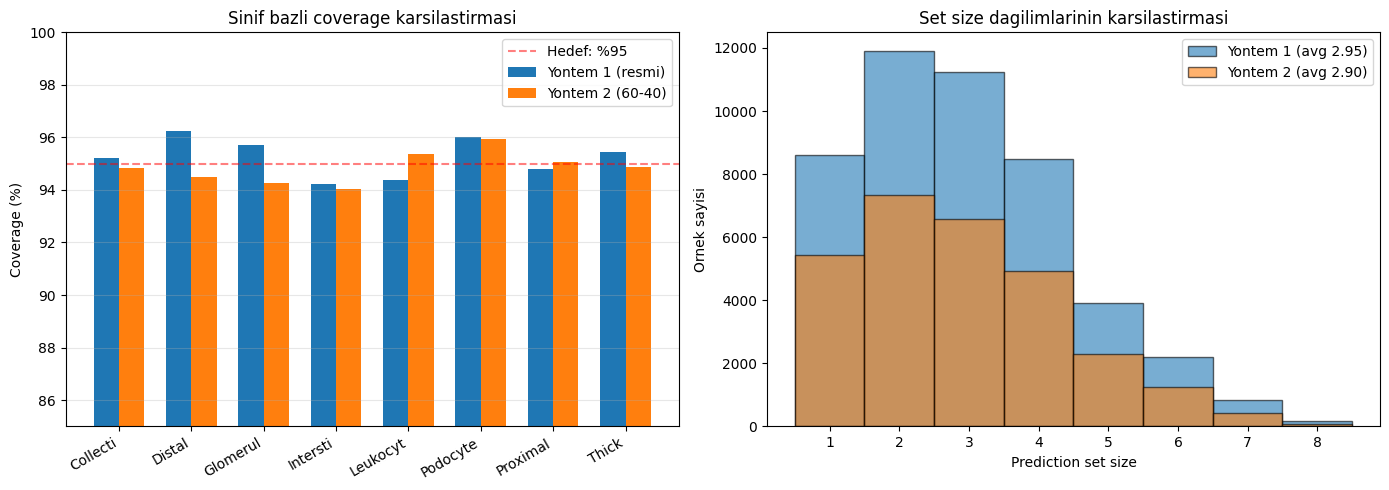


=== KARSILASTIRMA TAMAMLANDI ===
Grafik: method_comparison_v1_vs_v2.png


In [4]:
# ==========================================================================
# YONTEM 2: val + test BIRLESTIRIP %60-40 boluntusu (CP exchangeability)
# ==========================================================================
# Yontem 1 (resmi split) zaten yapildi. Simdi gorseldeki yontem ile
# tekrar hesaplayip sonuclari karsilastiralim.

import torch
from torch.utils.data import ConcatDataset, random_split, DataLoader

# ---------- 1) val + test setlerini birlestir, %60 calib + %40 test bol ----------
combined = ConcatDataset([val_dataset, test_dataset])
n_total  = len(combined)
n_calib  = int(0.6 * n_total)
n_test_new = n_total - n_calib

print(f"Toplam (val + test): {n_total}")
print(f"Yeni calibration: {n_calib}")
print(f"Yeni test:        {n_test_new}")

# Reproducibility icin sabit seed
generator = torch.Generator().manual_seed(42)
calib_subset, test_subset_new = random_split(
    combined, [n_calib, n_test_new], generator=generator
)

calib_loader_v2 = DataLoader(calib_subset,    batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=NUM_WORKERS)
test_loader_v2  = DataLoader(test_subset_new, batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=NUM_WORKERS)

# ---------- 2) Yeni split icin olasiliklari hesapla ----------
# En iyi checkpoint'i (run_3) tekrar yukle
best_model = load_model(checkpoints[best_name])
print(f"\nModel: {best_name}")

print("Calibration olasiliklari...")
calib_probs, calib_labels = get_probs_and_labels(calib_loader_v2, best_model, device)
print("Test olasiliklari...")
test_probs_v2, test_labels_v2 = get_probs_and_labels(test_loader_v2, best_model, device)

n_calib_v2 = len(calib_probs)
n_test_v2  = len(test_probs_v2)
print(f"Calib: {n_calib_v2} | Test: {n_test_v2}")


# ---------- 3) Class-conditional LAC: yeni split ile ----------
ALPHA_V2 = 0.05  # %95 guven (yontem 1 ile ayni icin)
TARGET_COV_V2 = 1 - ALPHA_V2

prob_thresholds_v2 = np.zeros(n_classes)
calib_per_class = np.zeros(n_classes, dtype=int)

print("\n" + "=" * 60)
print("  YONTEM 2: VAL+TEST %60-40 SPLIT, CLASS-CONDITIONAL LAC")
print("=" * 60)
print(f"\n--- %{int(TARGET_COV_V2*100)} GUVEN ICIN ESIKLER (Calib uzerinden) ---")

for c in range(n_classes):
    mask = calib_labels == c
    n_c = mask.sum()
    calib_per_class[c] = n_c
    if n_c == 0:
        prob_thresholds_v2[c] = 0.0
        continue
    true_probs = calib_probs[mask, c]
    q_level = np.floor((n_c + 1) * ALPHA_V2) / n_c
    q_level = max(q_level, 0.0)
    prob_thresholds_v2[c] = np.quantile(true_probs, q_level, method="lower")
    name = class_names[c][:22]
    print(f"Sinif {c} ({name:22s}) Esik: {prob_thresholds_v2[c]:.4f}  ({n_c} ornek)")

# Test setine uygula
y_set_v2 = test_probs_v2 >= prob_thresholds_v2[np.newaxis, :]
empty = y_set_v2.sum(axis=1) == 0
if empty.any():
    top1 = test_probs_v2[empty].argmax(axis=1)
    y_set_v2[empty, top1] = True

global_cov_v2 = y_set_v2[np.arange(n_test_v2), test_labels_v2].mean()
mean_size_v2  = y_set_v2.sum(axis=1).mean()

print(f"\nGlobal Coverage: %{global_cov_v2*100:.2f}")
print(f"Mean Set Size:   {mean_size_v2:.2f}")

print(f"\n--- Sinif Bazli Coverage ---")
per_class_cov_v2 = []
for c in range(n_classes):
    mask = test_labels_v2 == c
    if mask.sum() == 0:
        per_class_cov_v2.append(np.nan); continue
    cov_c = y_set_v2[mask, c].mean()
    per_class_cov_v2.append(cov_c)
    short = class_names[c].split(",")[0].split(" ")[0][:11]
    print(f"{short:12s}: %{cov_c*100:.2f}")


# ---------- 4) IKI YONTEMI KARSILASTIR ----------
# Yontem 1 sonuclari onceki hucreden geliyor:
#   global_cov, mean_size, prob_thresholds, y_set_cc

print("\n" + "=" * 60)
print("  IKI YONTEMIN KARSILASTIRMASI")
print("=" * 60)

print(f"\n{'Metrik':<30s} {'Yontem 1':>12s} {'Yontem 2':>12s}")
print(f"{'(resmi split)':<30s} {'':>12s} {'(60-40 split)':>12s}")
print("-" * 56)
print(f"{'Calibration boyutu':<30s} {n_val:>12d} {n_calib_v2:>12d}")
print(f"{'Test boyutu':<30s} {n_test:>12d} {n_test_v2:>12d}")
print(f"{'Global Coverage':<30s} {global_cov*100:>11.2f}% {global_cov_v2*100:>11.2f}%")
print(f"{'Mean Set Size':<30s} {mean_size:>12.2f} {mean_size_v2:>12.2f}")

# Sinif bazli karsilastirma
print(f"\n{'Sinif':<14s} {'Yontem 1':>10s} {'Yontem 2':>10s}")
print("-" * 36)
for c in range(n_classes):
    mask1 = test_labels == c
    cov1 = y_set_cc[mask1, c].mean() if mask1.sum() > 0 else np.nan
    cov2 = per_class_cov_v2[c]
    short = class_names[c].split(",")[0].split(" ")[0][:11]
    print(f"{short:<14s} {cov1*100:>9.2f}% {cov2*100:>9.2f}%")

# Threshold karsilastirmasi
print(f"\n{'Sinif':<14s} {'Yontem 1':>10s} {'Yontem 2':>10s}")
print(f"{'Threshold':<14s}")
print("-" * 36)
for c in range(n_classes):
    short = class_names[c].split(",")[0].split(" ")[0][:11]
    print(f"{short:<14s} {prob_thresholds[c]:>10.4f} {prob_thresholds_v2[c]:>10.4f}")


# ---------- 5) Gorsel karsilastirma ----------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Sinif bazli coverage cubuk grafigi
ax = axes[0]
x = np.arange(n_classes)
width = 0.35
cov1_arr = np.array([y_set_cc[test_labels == c, c].mean() if (test_labels == c).sum() > 0 else 0
                      for c in range(n_classes)])
cov2_arr = np.array(per_class_cov_v2)
ax.bar(x - width/2, cov1_arr * 100, width, label="Yontem 1 (resmi)", color="tab:blue")
ax.bar(x + width/2, cov2_arr * 100, width, label="Yontem 2 (60-40)", color="tab:orange")
ax.axhline(95, color="red", linestyle="--", alpha=0.5, label="Hedef: %95")
ax.set_xticks(x)
ax.set_xticklabels([class_names[c].split(",")[0].split(" ")[0][:8] for c in range(n_classes)],
                   rotation=30, ha="right")
ax.set_ylabel("Coverage (%)")
ax.set_title("Sinif bazli coverage karsilastirmasi")
ax.set_ylim(85, 100)
ax.legend()
ax.grid(alpha=0.3, axis="y")

# (b) Set size dagilimi
ax = axes[1]
sizes_v1 = y_set_cc.sum(axis=1)
sizes_v2 = y_set_v2.sum(axis=1)
bins = np.arange(0.5, n_classes + 1.5, 1)
ax.hist(sizes_v1, bins=bins, alpha=0.6, label=f"Yontem 1 (avg {sizes_v1.mean():.2f})",
        edgecolor="black", color="tab:blue")
ax.hist(sizes_v2, bins=bins, alpha=0.6, label=f"Yontem 2 (avg {sizes_v2.mean():.2f})",
        edgecolor="black", color="tab:orange")
ax.set_xlabel("Prediction set size")
ax.set_ylabel("Ornek sayisi")
ax.set_title("Set size dagilimlarinin karsilastirmasi")
ax.set_xticks(range(1, n_classes + 1))
ax.legend()

plt.tight_layout()
plt.savefig("method_comparison_v1_vs_v2.png", dpi=150)
plt.show()

print("\n=== KARSILASTIRMA TAMAMLANDI ===")
print("Grafik: method_comparison_v1_vs_v2.png")

In [5]:
# ==========================================================================
# HARD EXAMPLE MINING: Modelin kararsiz kaldigi ornekler
# ==========================================================================
# Conformal prediction'in pratik faydasi: set size'i buyuk olan ornekler
# = modelin gercekten zorlandigi ornekler. Bunlari bulup gosterelim.

import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# Yontem 1'de y_set_cc var (class-conditional LAC sonucu, %95 guven)
# Onu kullanalim. Eger Yontem 2'yi tercih edersen y_set_v2'yi kullanirsin.

set_sizes = y_set_cc.sum(axis=1)
print("=" * 60)
print("  HARD EXAMPLE MINING (CP UNCERTAINTY ANALYSIS)")
print("=" * 60)

# Set size dagilimi
print("\n--- Set Size Dagilimi ---")
for k in range(1, n_classes + 1):
    n_k = (set_sizes == k).sum()
    if n_k > 0:
        pct = 100 * n_k / len(set_sizes)
        bar = "█" * int(pct / 2)
        print(f"  |set| = {k}: {n_k:6d} ornek ({pct:5.2f}%) {bar}")

# Zor ornekler: set size >= 3
hard_indices = np.where(set_sizes >= 3)[0]
easy_indices = np.where(set_sizes == 1)[0]

print(f"\n--- Zorluk Analizi ---")
print(f"Kolay ornek (set=1): {len(easy_indices):6d} ({100*len(easy_indices)/len(set_sizes):.2f}%)")
print(f"Zor ornek   (set>=3): {len(hard_indices):6d} ({100*len(hard_indices)/len(set_sizes):.2f}%)")
print(f"Kolay orneklerde model emin, zor orneklerde belirsiz.")

# Sinif bazinda ortalama set size (zorluk derecesi)
print(f"\n--- Sinif Bazli Ortalama Set Size (Zorluk Derecesi) ---")
class_difficulty = []
for c in range(n_classes):
    mask = test_labels == c
    if mask.sum() > 0:
        avg_size = set_sizes[mask].mean()
        class_difficulty.append((c, class_names[c], avg_size))

# Zorlugu yuksekten dusuge sirala
class_difficulty.sort(key=lambda x: -x[2])
print(f"{'Sinif':<35s} {'Avg Set Size':>12s}")
print("-" * 50)
for c, name, avg in class_difficulty:
    bar = "█" * int(avg * 5)
    print(f"{name[:33]:<35s} {avg:>12.2f}  {bar}")

  HARD EXAMPLE MINING (CP UNCERTAINTY ANALYSIS)

--- Set Size Dagilimi ---
  |set| = 1:   8600 ornek (18.19%) █████████
  |set| = 2:  11901 ornek (25.17%) ████████████
  |set| = 3:  11226 ornek (23.74%) ███████████
  |set| = 4:   8484 ornek (17.94%) ████████
  |set| = 5:   3897 ornek ( 8.24%) ████
  |set| = 6:   2192 ornek ( 4.64%) ██
  |set| = 7:    821 ornek ( 1.74%) 
  |set| = 8:    159 ornek ( 0.34%) 

--- Zorluk Analizi ---
Kolay ornek (set=1):   8600 (18.19%)
Zor ornek   (set>=3):  26779 (56.64%)
Kolay orneklerde model emin, zor orneklerde belirsiz.

--- Sinif Bazli Ortalama Set Size (Zorluk Derecesi) ---
Sinif                               Avg Set Size
--------------------------------------------------
Podocytes                                   4.45  ██████████████████████
Glomerular endothelial cells                4.09  ████████████████████
Leukocytes                                  3.56  █████████████████
Interstitial endothelial cells              3.49  █████████████████
D

Gosterilen ornek sayisi: 6 (set size >= 4)


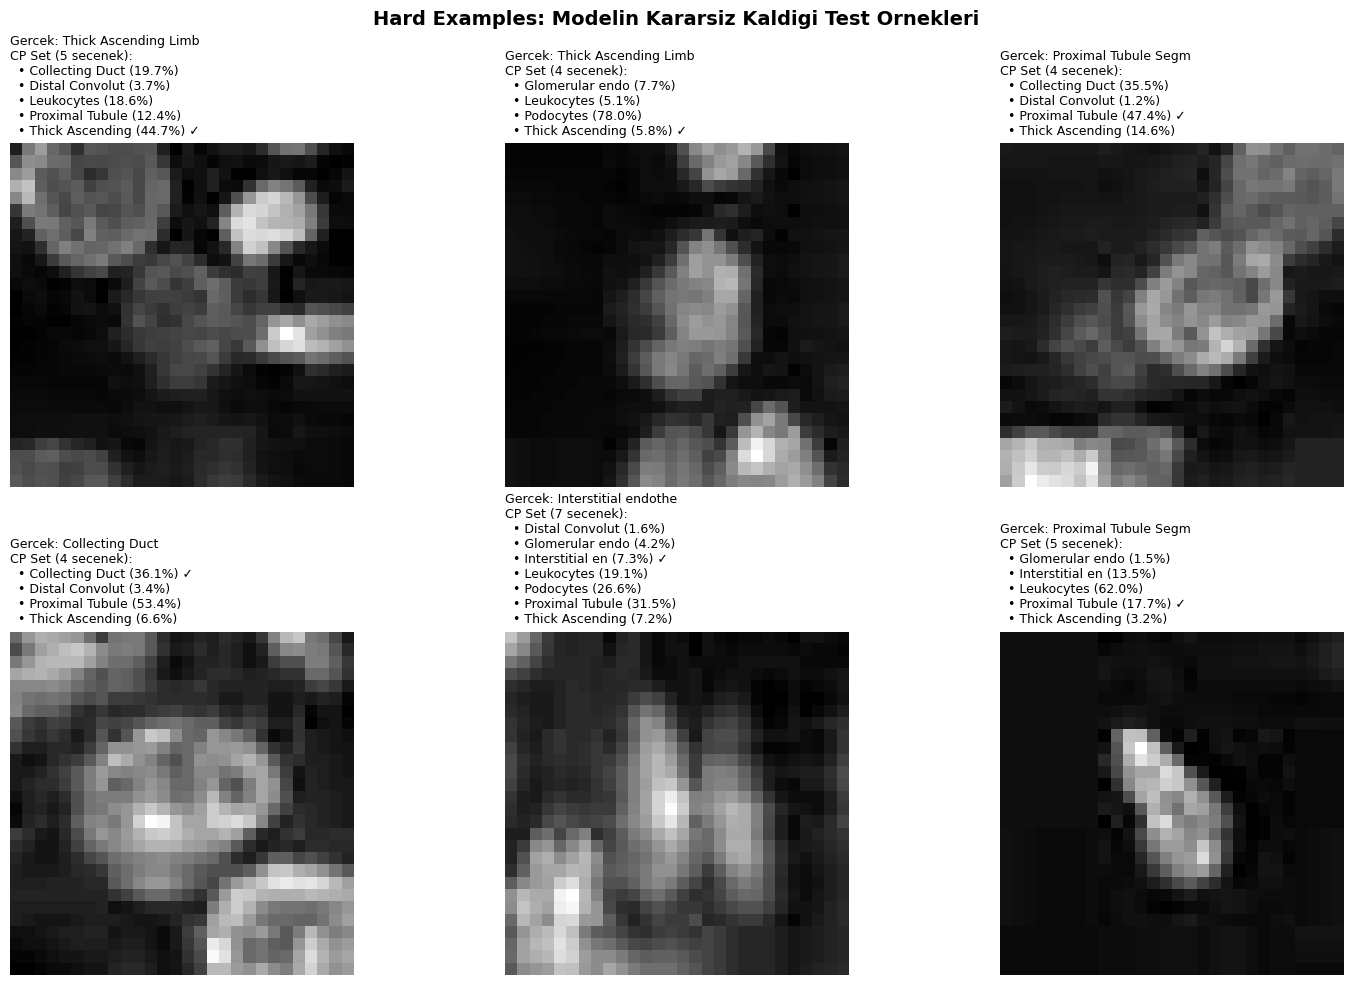


Gorsel kaydedildi: hard_examples.png

** Yorumlama **
Bu ornekler modelin tek bir tahmin yapmaktan kacindigi durumlardir.
Conformal prediction sayesinde model 'emin degilim, bu siniflardan biri' diyebiliyor.
Tibbi karar verme sureclerinde bu bilgi cok degerli — kullanici/doktor
bu ornekler icin ek inceleme yapabilir.


In [6]:
# ==========================================================================
# HARD EXAMPLES'I GORSELLESTIR
# ==========================================================================
# Test setinde modelin en kararsiz oldugu ornekleri imaj olarak gosterelim

# Test datasetini ham (transform'siz) hali ile yeniden yukle ki gorebilelim
from torchvision import transforms as T

vis_transform = T.Compose([T.ToTensor()])  # sadece tensor yap
test_dataset_vis = DataClass(split="test", transform=vis_transform, download=True)

# Set size 4+ olanlardan ilk 6 ornegi sec
very_hard = np.where(set_sizes >= 4)[0]
if len(very_hard) == 0:
    very_hard = np.where(set_sizes >= 3)[0]

n_show = min(6, len(very_hard))
print(f"Gosterilen ornek sayisi: {n_show} (set size >= {set_sizes[very_hard].min()})")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i in range(n_show):
    idx = very_hard[i]
    img, _ = test_dataset_vis[idx]
    img_np = img.squeeze().numpy()  # 28x28 grayscale

    # Gercek sinif
    true_c = test_labels[idx]
    true_name = class_names[true_c].split(",")[0][:20]

    # CP setindeki siniflar ve olasiliklari
    set_classes = np.where(y_set_cc[idx])[0]
    set_info = []
    for c in set_classes:
        prob = test_probs[idx, c] * 100
        cname = class_names[c].split(",")[0][:15]
        marker = " ✓" if c == true_c else ""
        set_info.append(f"  • {cname} ({prob:.1f}%){marker}")

    axes[i].imshow(img_np, cmap="gray")
    axes[i].axis("off")
    title = f"Gercek: {true_name}\nCP Set ({len(set_classes)} secenek):\n" + "\n".join(set_info)
    axes[i].set_title(title, fontsize=9, loc="left")

# Bos kalan subplot'lari kapat
for j in range(n_show, len(axes)):
    axes[j].axis("off")

plt.suptitle("Hard Examples: Modelin Kararsiz Kaldigi Test Ornekleri",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("hard_examples.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nGorsel kaydedildi: hard_examples.png")
print("\n** Yorumlama **")
print("Bu ornekler modelin tek bir tahmin yapmaktan kacindigi durumlardir.")
print("Conformal prediction sayesinde model 'emin degilim, bu siniflardan biri' diyebiliyor.")
print("Tibbi karar verme sureclerinde bu bilgi cok degerli — kullanici/doktor")
print("bu ornekler icin ek inceleme yapabilir.")

In [7]:
!pip install grad-cam -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 65.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


Her sinif icin bir ornek bulundu: 8 sinif


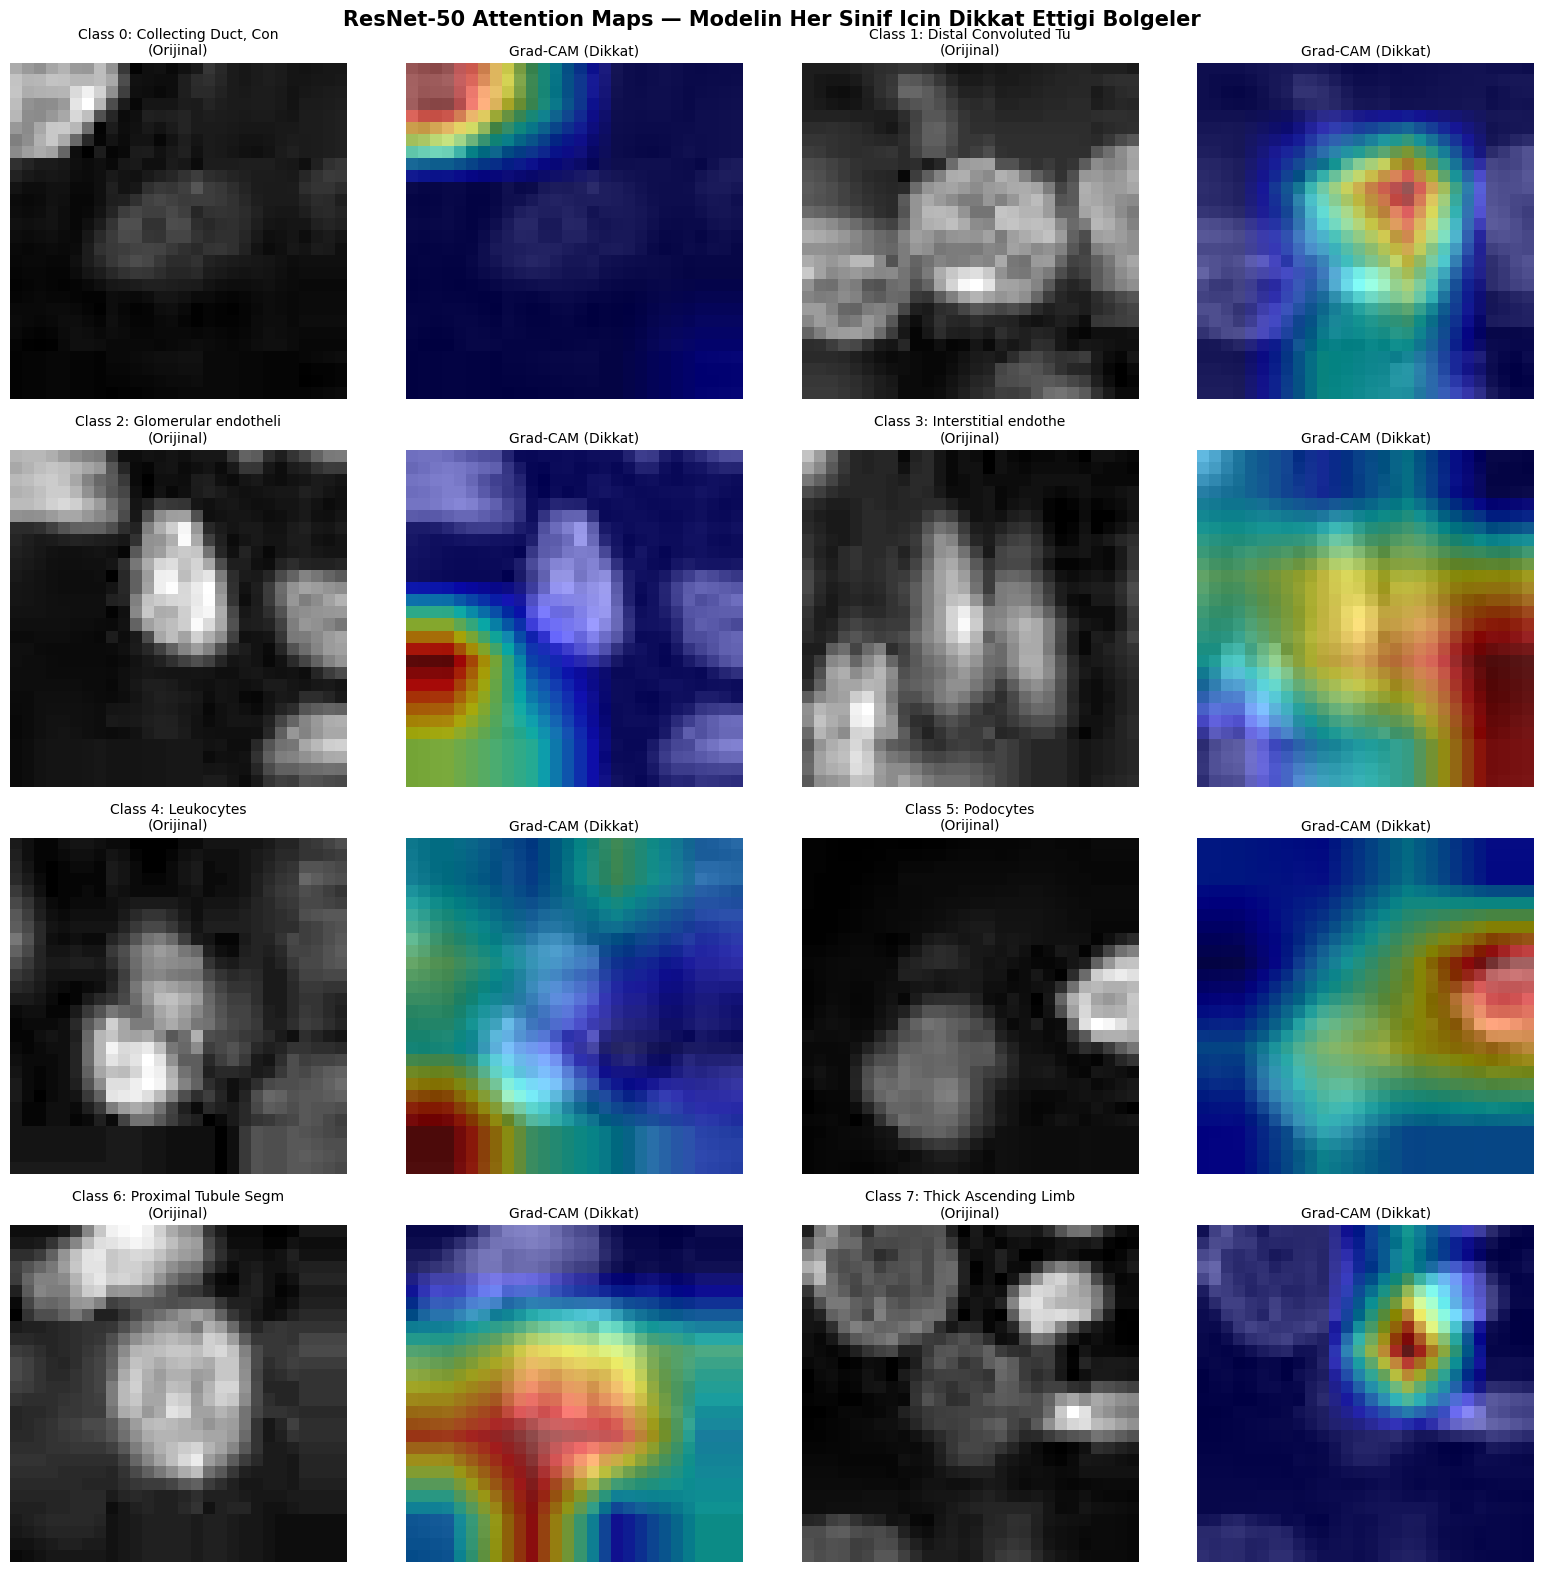


Gorsel kaydedildi: attention_maps.png

** Yorumlama **
Kirmizi-sari bolgeler: modelin o sinifa karar vermek icin onemli buldugu yerler
Mavi bolgeler: modelin onemsiz buldugu yerler
Bu, modelin gercekten anlamli ozellikleri ogrenip ogrenmedigini kontrol eder.


In [8]:
# ==========================================================================
# GRAD-CAM ATTENTION MAPS: Modelin nereye baktigini gor
# ==========================================================================
# ResNet-50 icin Grad-CAM. Her sinif icin bir test ornegi al ve modelin
# o sinifa karar vermek icin imajin hangi bolgesine "dikkat ettigini" goster.

import torch
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Model: en iyi run_3 modelini tekrar yukle
model_gradcam = load_model(checkpoints[best_name])
model_gradcam.eval()

# ResNet-50'nin son convolutional katmani (Grad-CAM icin)
# MedMNIST'in ozel mimarisinde son layer4'un son blogunun son conv katmani
target_layers = [model_gradcam.layer4[-1].conv3]

# GradCAM nesnesi
cam = GradCAM(model=model_gradcam, target_layers=target_layers)

# Her sinif icin ilk test ornegini bul
class_samples = {}
test_dataset_full = DataClass(split="test", transform=transform_28, download=True)

for idx in range(len(test_dataset_full)):
    img, label = test_dataset_full[idx]
    lbl = int(label.item()) if hasattr(label, 'item') else int(label[0])
    if lbl not in class_samples:
        class_samples[lbl] = (img, idx)
    if len(class_samples) == n_classes:
        break

print(f"Her sinif icin bir ornek bulundu: {len(class_samples)} sinif")

# 4x2 grid ile 8 sinifin Grad-CAM'i
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
fig.suptitle("ResNet-50 Attention Maps — Modelin Her Sinif Icin Dikkat Ettigi Bolgeler",
             fontsize=15, fontweight="bold")

for cls_idx in range(n_classes):
    img_tensor, _ = class_samples[cls_idx]
    img_tensor = img_tensor.unsqueeze(0).to(device)

    # Bu sinif icin Grad-CAM hesapla
    targets = [ClassifierOutputTarget(cls_idx)]
    grayscale_cam = cam(input_tensor=img_tensor, targets=targets)[0, :]

    # Orijinal imaji hazirla (gosterim icin)
    img_np = img_tensor.cpu().squeeze().numpy()
    if img_np.ndim == 3 and img_np.shape[0] == 3:
        img_np = np.transpose(img_np, (1, 2, 0))
    # 0-1 arasina normalize
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)
    if img_np.ndim == 2:
        img_np = np.stack([img_np] * 3, axis=-1)

    # Heatmap'i imaja yap
    visualization = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    # Subplot'u hesapla (4x4 grid'de 8 sinif)
    row = cls_idx // 2
    col_base = (cls_idx % 2) * 2

    # Sol: orijinal imaj
    axes[row, col_base].imshow(img_np)
    axes[row, col_base].axis("off")
    axes[row, col_base].set_title(f"Class {cls_idx}: {class_names[cls_idx][:20]}\n(Orijinal)",
                                    fontsize=10)

    # Sag: Grad-CAM overlay
    axes[row, col_base + 1].imshow(visualization)
    axes[row, col_base + 1].axis("off")
    axes[row, col_base + 1].set_title("Grad-CAM (Dikkat)", fontsize=10)

plt.tight_layout()
plt.savefig("attention_maps.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nGorsel kaydedildi: attention_maps.png")
print("\n** Yorumlama **")
print("Kirmizi-sari bolgeler: modelin o sinifa karar vermek icin onemli buldugu yerler")
print("Mavi bolgeler: modelin onemsiz buldugu yerler")
print("Bu, modelin gercekten anlamli ozellikleri ogrenip ogrenmedigini kontrol eder.")

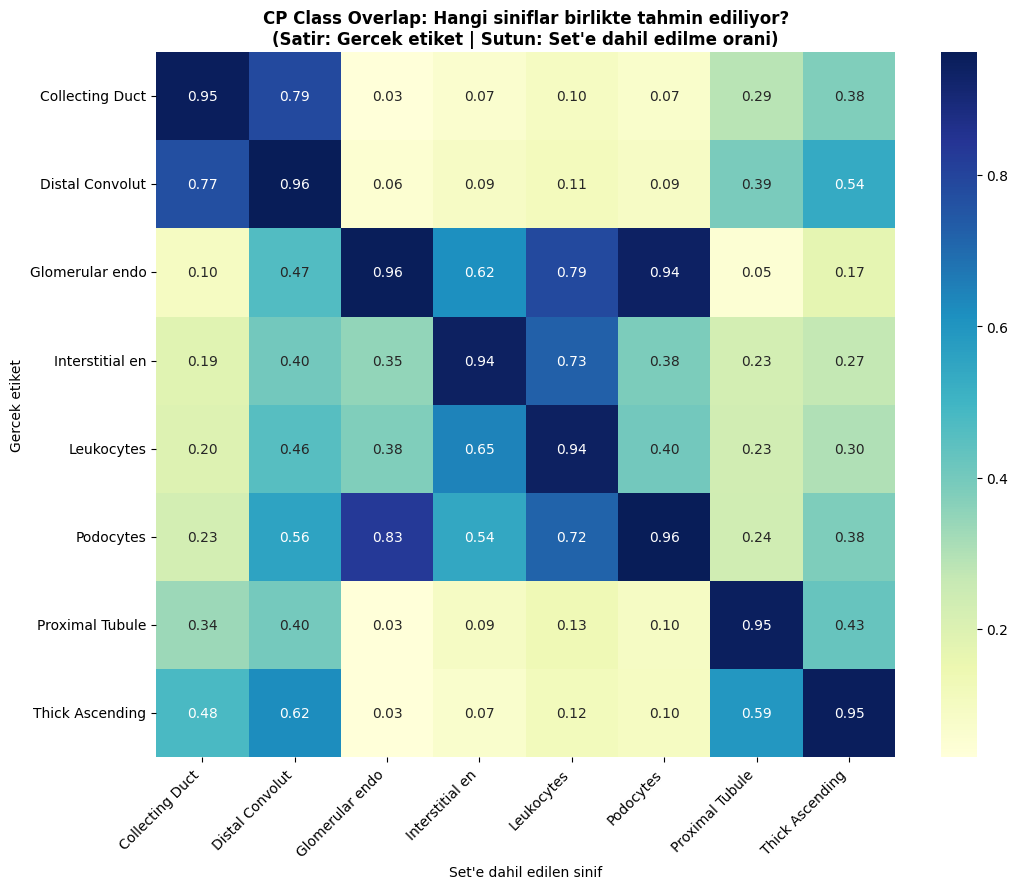

In [9]:
# Yeni hucre
import seaborn as sns
import matplotlib.pyplot as plt

# CP class overlap: Gercek sinif i iken, sinif j kac kez set'e dahil edilmis?
overlap_matrix = np.zeros((n_classes, n_classes))
for i in range(n_classes):
    mask = test_labels == i
    if mask.sum() > 0:
        overlap_matrix[i] = y_set_cc[mask].mean(axis=0)

plt.figure(figsize=(11, 9))
sns.heatmap(overlap_matrix, annot=True, fmt=".2f", cmap="YlGnBu",
            xticklabels=[c.split(",")[0][:15] for c in class_names],
            yticklabels=[c.split(",")[0][:15] for c in class_names])
plt.title("CP Class Overlap: Hangi siniflar birlikte tahmin ediliyor?\n"
          "(Satir: Gercek etiket | Sutun: Set'e dahil edilme orani)",
          fontweight="bold")
plt.xlabel("Set'e dahil edilen sinif")
plt.ylabel("Gercek etiket")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("cp_class_overlap.png", dpi=150)
plt.show()

In [10]:
import os
import zipfile
import numpy as np

# Hangi dosyalari pakete koyacagiz
output_zip = "tissuemnist_results.zip"

with zipfile.ZipFile(output_zip, "w", zipfile.ZIP_DEFLATED) as zf:
    # Numpy dosyalarini olustur ve ekle
    np.save("test_probabilities.npy", test_probs)
    np.save("test_labels.npy", test_labels)
    np.save("val_probabilities.npy", val_probs)
    np.save("val_labels.npy", val_labels)
    np.save("y_set_cc_method1.npy", y_set_cc)
    np.save("thresholds_method1.npy", prob_thresholds)
    if 'y_set_v2' in dir():
        np.save("y_set_cc_method2.npy", y_set_v2)
    if 'prob_thresholds_v2' in dir():
        np.save("thresholds_method2.npy", prob_thresholds_v2)

    # Tum dosyalari zip'e ekle
    files = [
        "test_probabilities.npy",
        "test_labels.npy",
        "val_probabilities.npy",
        "val_labels.npy",
        "y_set_cc_method1.npy",
        "y_set_cc_method2.npy",
        "thresholds_method1.npy",
        "thresholds_method2.npy",
    ]
    for f in files:
        if os.path.exists(f):
            zf.write(f)
            print(f"  ✓ {f}")

print(f"\nZip olusturuldu: {output_zip}")
print(f"Boyut: {os.path.getsize(output_zip) / 1024:.1f} KB")

# Otomatik indirme
from google.colab import files
files.download(output_zip)

  ✓ test_probabilities.npy
  ✓ test_labels.npy
  ✓ val_probabilities.npy
  ✓ val_labels.npy
  ✓ y_set_cc_method1.npy
  ✓ y_set_cc_method2.npy
  ✓ thresholds_method1.npy
  ✓ thresholds_method2.npy

Zip olusturuldu: tissuemnist_results.zip
Boyut: 2232.8 KB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
from google.colab import files
files.download("weights_tissuemnist/resnet50_28_3.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>